# Skin-lesion training, PSO/BAT tuning, testing, and Grad-CAM

This notebook keeps the test set untouched while comparing a baseline, Particle Swarm Optimization (PSO), and the Bat Algorithm (BAT). Both searches tune transfer-learning hyperparameters using **validation macro-F1**. After choosing one configuration, it retrains once and evaluates on the held-out test set.

> This is research software, not a medical device. Grad-CAM indicates regions influencing a model prediction; it is not lesion segmentation or a clinical diagnosis.

## 1. Dataset layout

Place images in the following `ImageFolder` layout. Class-folder names must match across all three splits. For a binary study, use `melanoma` and `non_melanoma`. Split by `lesion_id`, not individual images, to avoid leakage from multiple images of the same lesion.

```text
data/images/train/<class-name>/*.jpg
data/images/valid/<class-name>/*.jpg
data/images/test/<class-name>/*.jpg
```

In [27]:
from pathlib import Path
import copy, json, random, sys

ROOT = Path.cwd()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

DATA_DIR = ROOT / 'data' / 'images'
if not DATA_DIR.is_dir():
    DATA_DIR = ROOT / 'split_dataset'
OUTPUT_DIR = ROOT / 'outputs'
CHECKPOINT = ROOT / 'models' / 'pso_bat_selected_model.pth'
ARCHITECTURE = 'mobilenet_v2'  # 'resnet18' is also supported
IMAGE_SIZE = 224
BATCH_SIZE = 32
WORKERS = 2
SEED = 42

assert (DATA_DIR / 'train').is_dir(), f"Missing {DATA_DIR / 'train'}"
assert (DATA_DIR / 'valid').is_dir(), f"Missing {DATA_DIR / 'valid'}"
assert (DATA_DIR / 'test').is_dir(), f"Missing {DATA_DIR / 'test'}"
print(f'Using dataset: {DATA_DIR}')

Using dataset: d:\Documents\skincancerdetection\split_dataset


In [28]:
import matplotlib.pyplot as plt
import importlib
import numpy as np
import pandas as pd
import torch
torch.hub.set_dir(str(ROOT / '.cache' / 'torch'))
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

import skin_cancer.data as data_module
importlib.reload(data_module)
from skin_cancer.data import evaluation_display_transform, evaluation_transform, imagefolder, make_eval_loader, make_train_loader, training_transform
from skin_cancer.gradcam import GradCAM, save_overlay
from skin_cancer.models import build_model, gradcam_layer
from skin_cancer.training import report, run_epoch, save_checkpoint, set_seed

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using {DEVICE}')

train_dataset = imagefolder(DATA_DIR / 'train', training_transform(IMAGE_SIZE))
valid_dataset = imagefolder(DATA_DIR / 'valid', evaluation_transform(IMAGE_SIZE))
test_dataset = imagefolder(DATA_DIR / 'test', evaluation_transform(IMAGE_SIZE))
assert train_dataset.classes == valid_dataset.classes == test_dataset.classes
CLASS_NAMES = train_dataset.classes
print(dict(zip(CLASS_NAMES, np.bincount(train_dataset.targets))))

train_loader = make_train_loader(train_dataset, BATCH_SIZE, WORKERS)
valid_loader = make_eval_loader(valid_dataset, BATCH_SIZE, WORKERS)
test_loader = make_eval_loader(test_dataset, BATCH_SIZE, WORKERS)

Using cuda
{'melanoma': np.int64(7408), 'others': np.int64(6303)}


## 2. Shared training function

The weighted sampler addresses unequal class counts. `macro_f1` is the selection metric because raw accuracy can hide poor minority-class performance.

{"epoch": 1, "train_loss": 0.2741, "valid_loss": 0.3086, "train_accuracy": 0.9207, "train_balanced_accuracy": 0.9207, "train_macro_f1": 0.9207, "train_roc_auc": 0.9764, "valid_accuracy": 0.8944, "valid_balanced_accuracy": 0.8945, "valid_macro_f1": 0.8938, "valid_roc_auc": 0.9783}
{"epoch": 2, "train_loss": 0.2203, "valid_loss": 0.3208, "train_accuracy": 0.9503, "train_balanced_accuracy": 0.9503, "train_macro_f1": 0.9503, "train_roc_auc": 0.9895, "valid_accuracy": 0.9007, "valid_balanced_accuracy": 0.9009, "valid_macro_f1": 0.9002, "valid_roc_auc": 0.9828}
{"epoch": 3, "train_loss": 0.1994, "valid_loss": 0.2922, "train_accuracy": 0.9611, "train_balanced_accuracy": 0.9611, "train_macro_f1": 0.9611, "train_roc_auc": 0.9924, "valid_accuracy": 0.913, "valid_balanced_accuracy": 0.9131, "valid_macro_f1": 0.9128, "valid_roc_auc": 0.9801}
{"epoch": 4, "train_loss": 0.2018, "valid_loss": 0.397, "train_accuracy": 0.9592, "train_balanced_accuracy": 0.9592, "train_macro_f1": 0.9592, "train_roc_auc"

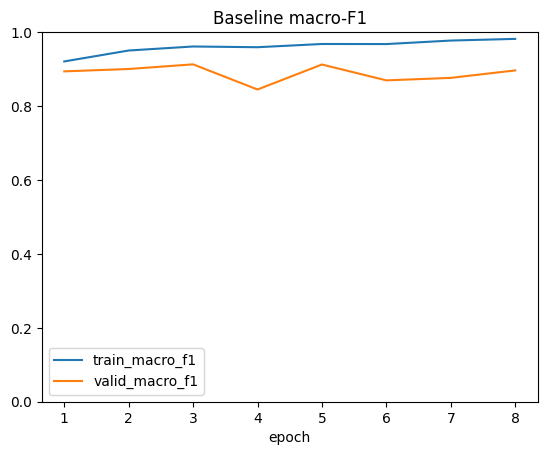

In [3]:
def fit(config, epochs, patience=5, verbose=True):
    model = build_model(ARCHITECTURE, len(CLASS_NAMES), pretrained=True, dropout=config['dropout']).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.3, patience=2)
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=DEVICE.type == 'cuda')
    best_f1, stale, best_state, best_metrics = -1.0, 0, None, None
    history = []
    for epoch in range(1, epochs + 1):
        train_loss, train_metrics, _, _ = run_epoch(model, train_loader, criterion, DEVICE, optimizer, scaler)
        valid_loss, valid_metrics, _, _ = run_epoch(model, valid_loader, criterion, DEVICE)
        scheduler.step(valid_metrics['macro_f1'])
        row = {'epoch': epoch, 'train_loss': train_loss, 'valid_loss': valid_loss, **{f'train_{k}': v for k, v in train_metrics.items()}, **{f'valid_{k}': v for k, v in valid_metrics.items()}}
        history.append(row)
        if verbose: print(json.dumps({k: round(v, 4) if isinstance(v, float) else v for k, v in row.items()}))
        if valid_metrics['macro_f1'] > best_f1:
            best_f1, stale = valid_metrics['macro_f1'], 0
            best_state, best_metrics = copy.deepcopy(model.state_dict()), valid_metrics.copy()
        else:
            stale += 1
        if stale >= patience:
            if verbose: print('Early stopping')
            break
    model.load_state_dict(best_state)
    return model, best_metrics, pd.DataFrame(history)

BASELINE = {'lr': 3e-4, 'dropout': 0.25, 'weight_decay': 1e-4}
BASELINE_EPOCHS = 12
baseline_model, baseline_valid, baseline_history = fit(BASELINE, BASELINE_EPOCHS)
print('Baseline validation:', baseline_valid)
baseline_history.plot(x='epoch', y=['train_macro_f1', 'valid_macro_f1'], title='Baseline macro-F1'); plt.ylim(0, 1); plt.show()

## 3. Search space and fair trial evaluator

Each trial trains briefly on the same training split and is ranked only on validation macro-F1. The logarithmic representation makes exploration of learning rate and weight decay more sensible. Increase `TUNING_EPOCHS`, `PARTICLES`, or `ITERATIONS` only after confirming the pipeline works; searches are expensive.

In [4]:
TUNING_EPOCHS = 4
PARTICLES = 5
ITERATIONS = 4
LOWER = np.array([-5.0, 0.10, -6.0])  # log10(lr), dropout, log10(weight_decay)
UPPER = np.array([-2.0, 0.50, -3.0])
trial_log = []

def decode(vector):
    vector = np.clip(np.asarray(vector, dtype=float), LOWER, UPPER)
    return {'lr': 10 ** vector[0], 'dropout': float(vector[1]), 'weight_decay': 10 ** vector[2]}

def score(vector, method, iteration, member):
    set_seed(SEED + iteration * 100 + member)
    config = decode(vector)
    model, metrics, _ = fit(config, epochs=TUNING_EPOCHS, patience=TUNING_EPOCHS, verbose=False)
    value = metrics['macro_f1']
    trial_log.append({'method': method, 'iteration': iteration, 'member': member, 'macro_f1': value, **config})
    del model
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()
    print(f'{method} iteration {iteration + 1}, member {member + 1}: F1={value:.4f}, {config}')
    return value

## 4. Particle Swarm Optimization (PSO)

PSO moves each particle toward its own best configuration and the best configuration found by the swarm.

In [5]:
def particle_swarm():
    rng = np.random.default_rng(SEED)
    position = rng.uniform(LOWER, UPPER, size=(PARTICLES, len(LOWER)))
    velocity = np.zeros_like(position)
    personal_best = position.copy()
    personal_scores = np.array([score(x, 'PSO', 0, i) for i, x in enumerate(position)])
    best_index = personal_scores.argmax(); global_best = personal_best[best_index].copy(); global_score = personal_scores[best_index]
    for iteration in range(1, ITERATIONS):
        r1, r2 = rng.random(position.shape), rng.random(position.shape)
        velocity = 0.65 * velocity + 1.4 * r1 * (personal_best - position) + 1.4 * r2 * (global_best - position)
        position = np.clip(position + velocity, LOWER, UPPER)
        scores = np.array([score(x, 'PSO', iteration, i) for i, x in enumerate(position)])
        improved = scores > personal_scores
        personal_best[improved], personal_scores[improved] = position[improved], scores[improved]
        if personal_scores.max() > global_score:
            best_index = personal_scores.argmax(); global_best, global_score = personal_best[best_index].copy(), personal_scores[best_index]
    return decode(global_best), float(global_score)

pso_config, pso_f1 = particle_swarm()
print('PSO best:', pso_config, 'validation macro-F1:', pso_f1)

PSO iteration 1, member 1: F1=0.9210, {'lr': np.float64(0.002098302729986613), 'dropout': 0.2755513759008209, 'weight_decay': np.float64(0.0003765249501831186)}
PSO iteration 1, member 2: F1=0.9276, {'lr': np.float64(0.0012362436879527078), 'dropout': 0.13767093915505982, 'weight_decay': np.float64(0.0008450201302139068)}
PSO iteration 1, member 3: F1=0.9024, {'lr': np.float64(0.0019205212018125557), 'dropout': 0.41442572211078155, 'weight_decay': np.float64(2.4229301715750363e-06)}
PSO iteration 1, member 4: F1=0.9120, {'lr': np.float64(0.00022446974525094094), 'dropout': 0.2483192096930325, 'weight_decay': np.float64(0.0006029689748608115)}
PSO iteration 1, member 5: F1=0.9180, {'lr': np.float64(0.000854270403311532), 'dropout': 0.42910464530833203, 'weight_decay': np.float64(2.1391566866988668e-05)}
PSO iteration 2, member 1: F1=0.9216, {'lr': np.float64(0.0012086505107249455), 'dropout': 0.1, 'weight_decay': np.float64(0.000544424642635722)}
PSO iteration 2, member 2: F1=0.9139, {'

## 5. Bat Algorithm (BAT)

BAT combines global movement toward the best bat with local random walks around the current best. Loudness decreases and pulse rate increases as trials improve.

In [6]:
def bat_algorithm():
    rng = np.random.default_rng(SEED + 1)
    position = rng.uniform(LOWER, UPPER, size=(PARTICLES, len(LOWER))); velocity = np.zeros_like(position)
    scores = np.array([score(x, 'BAT', 0, i) for i, x in enumerate(position)])
    best_index = scores.argmax(); best, best_score = position[best_index].copy(), scores[best_index]
    loudness = np.ones(PARTICLES); pulse = np.full(PARTICLES, 0.5)
    for iteration in range(1, ITERATIONS):
        for i in range(PARTICLES):
            frequency = rng.uniform(0.0, 2.0)
            candidate_velocity = velocity[i] + (position[i] - best) * frequency
            candidate = position[i] + candidate_velocity
            if rng.random() > pulse[i]: candidate = best + rng.normal(0, 0.08, len(LOWER)) * (UPPER - LOWER)
            candidate = np.clip(candidate, LOWER, UPPER); candidate_score = score(candidate, 'BAT', iteration, i)
            if candidate_score >= scores[i] and rng.random() < loudness[i]:
                position[i], velocity[i], scores[i] = candidate, candidate_velocity, candidate_score
                loudness[i] *= 0.9; pulse[i] = 1 - np.exp(-0.3 * (iteration + 1))
            if candidate_score > best_score: best, best_score = candidate.copy(), candidate_score
    return decode(best), float(best_score)

bat_config, bat_f1 = bat_algorithm()
print('BAT best:', bat_config, 'validation macro-F1:', bat_f1)

BAT iteration 1, member 1: F1=0.9230, {'lr': np.float64(0.0009055194603720449), 'dropout': 0.11751012945559865, 'weight_decay': np.float64(1.148388303836885e-06)}
BAT iteration 1, member 2: F1=0.9185, {'lr': np.float64(0.00329334893701581), 'dropout': 0.33485721903522336, 'weight_decay': np.float64(4.721888096964874e-06)}
BAT iteration 1, member 3: F1=0.9217, {'lr': np.float64(0.0018004323821564912), 'dropout': 0.2054768789913499, 'weight_decay': np.float64(1.8194232038632502e-05)}
BAT iteration 1, member 4: F1=0.9299, {'lr': np.float64(0.00022547280151353325), 'dropout': 0.4821258316884951, 'weight_decay': np.float64(0.00047391996803538097)}
BAT iteration 1, member 5: F1=0.9349, {'lr': np.float64(6.853289479051158e-05), 'dropout': 0.21141371911175028, 'weight_decay': np.float64(1.8450100006519306e-05)}
BAT iteration 2, member 1: F1=0.9075, {'lr': np.float64(0.0009247834245257458), 'dropout': 0.1167443034279688, 'weight_decay': np.float64(1.1226749236449714e-06)}
BAT iteration 2, membe

## 6. Select, retrain, and save the winner

Compare baseline, PSO, and BAT by validation score. The winning setting is then trained longer and saved with the class names and image size required for safe later inference.

,method,macro_f1,lr,dropout,weight_decay
1,PSO,0.940748,0.001141,0.117508,0.001000
2,BAT,0.934879,0.000069,0.211414,0.000018
0,Baseline,0.912801,0.000300,0.250000,0.000100


,method,iteration,member,macro_f1,lr,dropout,weight_decay
19,PSO,3,4,0.940748,0.001141,0.117508,0.001000
16,PSO,3,1,0.935301,0.001203,0.159782,0.000980
24,BAT,0,4,0.934879,0.000069,0.211414,0.000018
14,PSO,2,4,0.932130,0.001174,0.190051,0.001000
31,BAT,2,1,0.931868,0.010000,0.471982,0.000001
23,BAT,0,3,0.929856,0.000225,0.482126,0.000474
33,BAT,2,3,0.929405,0.000610,0.500000,0.001000
30,BAT,2,0,0.928389,0.010000,0.100000,0.000001
1,PSO,0,1,0.927586,0.001236,0.137671,0.000845
38,BAT,3,3,0.925151,0.000485,0.500000,0.001000


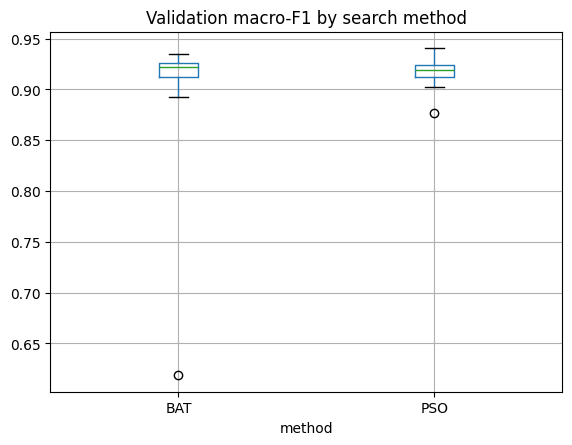

{"epoch": 1, "train_loss": 0.2821, "valid_loss": 0.2634, "train_accuracy": 0.9177, "train_balanced_accuracy": 0.9178, "train_macro_f1": 0.9177, "train_roc_auc": 0.9729, "valid_accuracy": 0.9253, "valid_balanced_accuracy": 0.9253, "valid_macro_f1": 0.9253, "valid_roc_auc": 0.9759}
{"epoch": 2, "train_loss": 0.2461, "valid_loss": 0.3067, "train_accuracy": 0.9349, "train_balanced_accuracy": 0.9349, "train_macro_f1": 0.9349, "train_roc_auc": 0.9819, "valid_accuracy": 0.8962, "valid_balanced_accuracy": 0.8963, "valid_macro_f1": 0.8958, "valid_roc_auc": 0.9733}
{"epoch": 3, "train_loss": 0.2329, "valid_loss": 0.3633, "train_accuracy": 0.9399, "train_balanced_accuracy": 0.94, "train_macro_f1": 0.9399, "train_roc_auc": 0.9854, "valid_accuracy": 0.8643, "valid_balanced_accuracy": 0.8645, "valid_macro_f1": 0.8633, "valid_roc_auc": 0.9622}
{"epoch": 4, "train_loss": 0.2156, "valid_loss": 0.4535, "train_accuracy": 0.9495, "train_balanced_accuracy": 0.9496, "train_macro_f1": 0.9495, "train_roc_auc"

In [7]:
comparison = pd.DataFrame([{'method': 'Baseline', 'macro_f1': baseline_valid['macro_f1'], **BASELINE}, {'method': 'PSO', 'macro_f1': pso_f1, **pso_config}, {'method': 'BAT', 'macro_f1': bat_f1, **bat_config}]).sort_values('macro_f1', ascending=False)
display(comparison)
trial_results = pd.DataFrame(trial_log)
display(trial_results.sort_values('macro_f1', ascending=False).head(10))
trial_results.boxplot(column='macro_f1', by='method'); plt.suptitle(''); plt.title('Validation macro-F1 by search method'); plt.show()

winner = comparison.iloc[0]
selected_config = {'lr': winner.lr, 'dropout': winner.dropout, 'weight_decay': winner.weight_decay}
FINAL_EPOCHS = 25
final_model, final_valid, final_history = fit(selected_config, epochs=FINAL_EPOCHS, patience=6)
save_checkpoint(CHECKPOINT, final_model, ARCHITECTURE, CLASS_NAMES, IMAGE_SIZE, final_valid)
print(f'Selected {winner.method}; checkpoint saved to {CHECKPOINT}')

## 7. Final held-out test

Run this after finalizing the configuration. Do not return to tuning based on these test results.

In [8]:
test_loss, test_metrics, test_labels, test_probabilities = run_epoch(final_model, test_loader, nn.CrossEntropyLoss(), DEVICE)
print(f'Test loss: {test_loss:.4f}')
print(test_metrics)
print(report(test_labels, test_probabilities, CLASS_NAMES))

Test loss: 0.2017
{'accuracy': 0.92, 'balanced_accuracy': 0.92, 'macro_f1': 0.91999199919992, 'roc_auc': 0.97645625}
              precision    recall  f1-score   support

    melanoma     0.9286    0.9100    0.9192       400
      others     0.9118    0.9300    0.9208       400

    accuracy                         0.9200       800
   macro avg     0.9202    0.9200    0.9200       800
weighted avg     0.9202    0.9200    0.9200       800



## 8. Random-image prediction and Grad-CAM localization

Use `IMAGE_TO_INSPECT` to override the random test image. The output panel is saved under `outputs/`.

Image: ISIC_0034196.jpg | actual: others | prediction: others (67.9%)


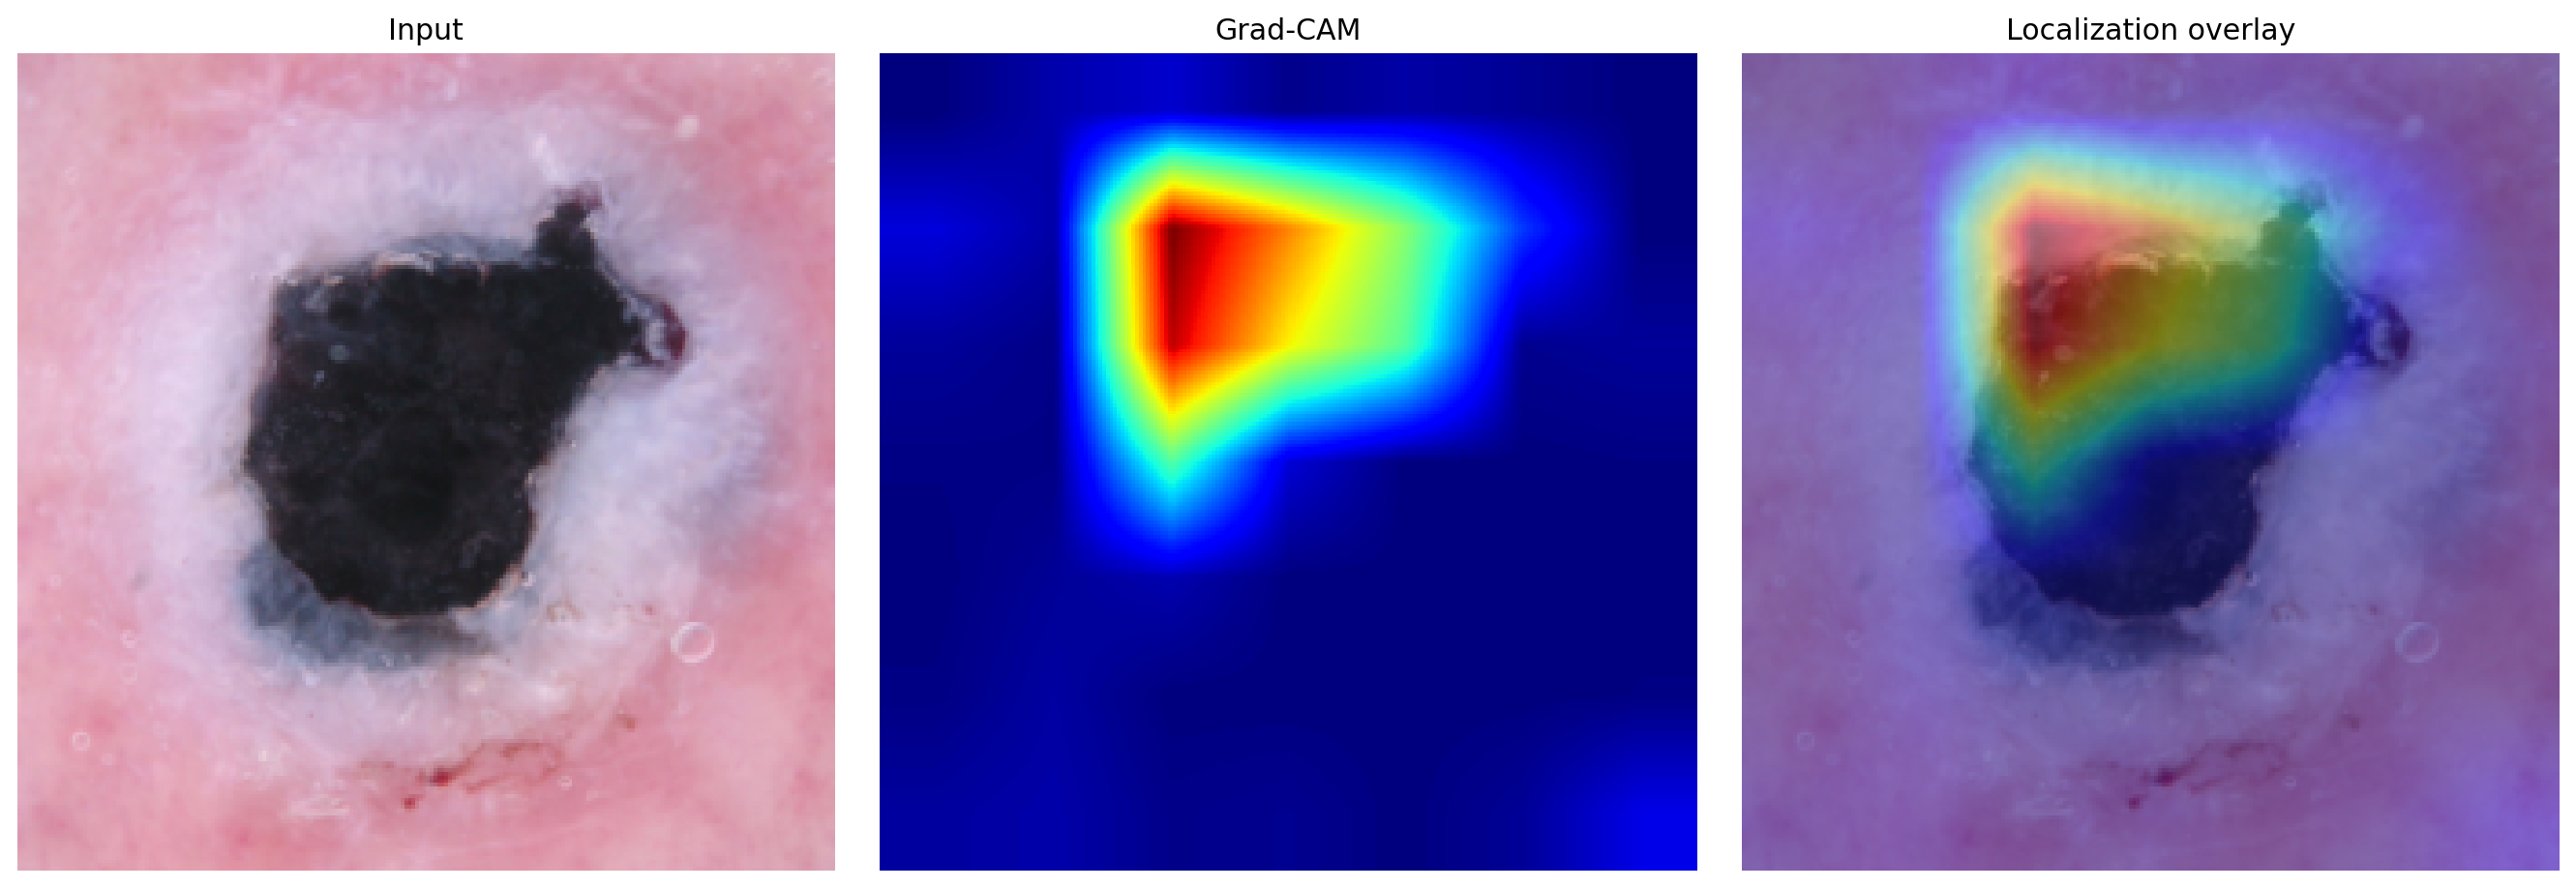

In [37]:
from PIL import Image
from IPython.display import display

IMAGE_TO_INSPECT = None
candidates = [p for p in (DATA_DIR / 'test').rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
image_path = Path(IMAGE_TO_INSPECT) if IMAGE_TO_INSPECT else random.Random().choice(candidates)
original = Image.open(image_path).convert('RGB')
display_image = evaluation_display_transform(IMAGE_SIZE)(original)
tensor = evaluation_transform(IMAGE_SIZE)(original).unsqueeze(0).to(DEVICE)
cam = GradCAM(final_model, gradcam_layer(final_model, ARCHITECTURE))
heatmap, predicted, confidence = cam.generate(tensor)
cam.close()
OUTPUT_DIR.mkdir(exist_ok=True)
heatmap_path = OUTPUT_DIR / 'random_gradcam.png'
save_overlay(original.resize((IMAGE_SIZE, IMAGE_SIZE)), heatmap, str(heatmap_path))
save_overlay(display_image, heatmap, str(heatmap_path))
actual = image_path.parent.name
print(f'Image: {image_path.name} | actual: {actual} | prediction: {CLASS_NAMES[predicted]} ({confidence:.1%})')
display(Image.open(heatmap_path))